In [1]:
from typing import Optional, Dict

import numpy as np
import matplotlib.pyplot as plt

import itertools

from pathlib import Path

from data import DynamicsDatasetMode

In [2]:
NONEMBED_BASE_DATA_DIR = Path("./nonembed_results")
SUBDIR_PATH = "dim_{dim}/radius_{radius}"

In [3]:
RADII = [0.5, 1.0, 2.0]
DIMS = [1, 2, 3, 4]
MODES = [
    "Single",
    "Multiple",
    "Multiple (w/ Validity)",
    "Ambient"
]
CONFIGS = [
    {"num_hidden_layers": 5, "num_nodes": 60, "label": "Cfg 1"},
    {"num_hidden_layers": 6, "num_nodes": 60, "label": "Cfg 2"},
    {"num_hidden_layers": 7, "num_nodes": 60, "label": "Cfg 3"}
]


def get_cfg(num_hidden_layers: int, num_nodes: int) -> int:
    for i in range(len(CONFIGS)):
        cfg = CONFIGS[i]
        if cfg["num_hidden_layers"] == num_hidden_layers and cfg["num_nodes"] == num_nodes:
            return i

    raise ValueError("configuration not found")


def get_cfg_label(num_hidden_layers: int, num_nodes: int) -> str:
    cfg = get_cfg(num_hidden_layers, num_nodes)
    return CONFIGS[cfg]["label"]

In [4]:
training_paths = []
for radius, dim in itertools.product(RADII, DIMS):
    data_dir = NONEMBED_BASE_DATA_DIR / str.format(SUBDIR_PATH, radius=radius, dim=dim)
    for child in data_dir.iterdir():
        if child.is_file() and child.name.endswith(".npz"):
            training_paths.append(child)

numpy_training_data = [
    np.load(path, allow_pickle=True) for path in training_paths
]

In [5]:
# process the training data into a more convenient format
training_data = []
for numpy_loaded in numpy_training_data:
    run = {
        "n": numpy_loaded["n"],
        "radius": numpy_loaded["radius"],
        "num_hidden_layers": numpy_loaded["num_hidden_layers"],
        "num_nodes_in_hidden_layer": numpy_loaded["num_nodes_in_hidden_layer"],
        "batch_size": numpy_loaded["batch_size"],
        "mode": numpy_loaded["mode"].item(),  # gets the enum from the object array
        "lr": numpy_loaded["lr"],
        "train_batch_loss_hist": numpy_loaded["train_batch_loss_hist_numpy"],
        "valid_batch_loss_hist": numpy_loaded["valid_batch_loss_hist_numpy"],
    }

    # computes the statistics on the runs
    train_max_batch_loss_hist = np.max(run["train_batch_loss_hist"], axis=1)
    train_min_batch_loss_hist = np.min(run["train_batch_loss_hist"], axis=1)
    train_mean_batch_loss_hist = np.mean(run["train_batch_loss_hist"], axis=1)

    valid_max_batch_loss_hist = np.max(run["valid_batch_loss_hist"], axis=1)
    valid_min_batch_loss_hist = np.min(run["valid_batch_loss_hist"], axis=1)
    valid_mean_batch_loss_hist = np.mean(run["valid_batch_loss_hist"], axis=1)

    run.update({
        "train_max_batch_loss_hist": train_max_batch_loss_hist,
        "train_min_batch_loss_hist": train_min_batch_loss_hist,
        "train_mean_batch_loss_hist": train_mean_batch_loss_hist,
        "valid_max_batch_loss_hist": valid_max_batch_loss_hist,
        "valid_min_batch_loss_hist": valid_min_batch_loss_hist,
        "valid_mean_batch_loss_hist": valid_mean_batch_loss_hist,
    })

    training_data.append(run)

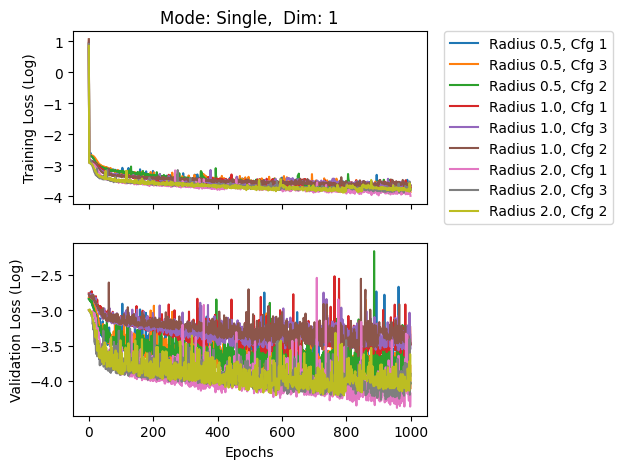

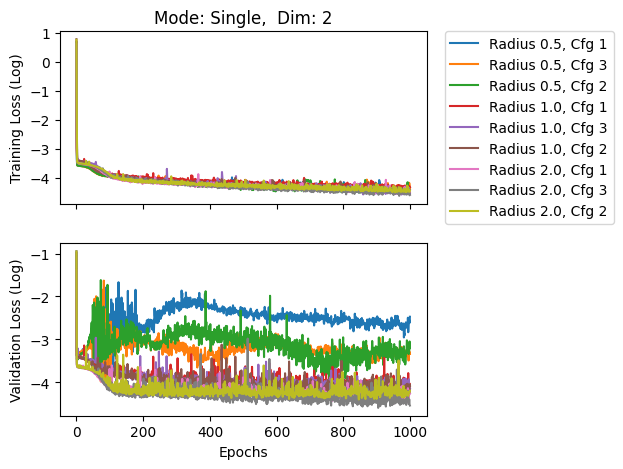

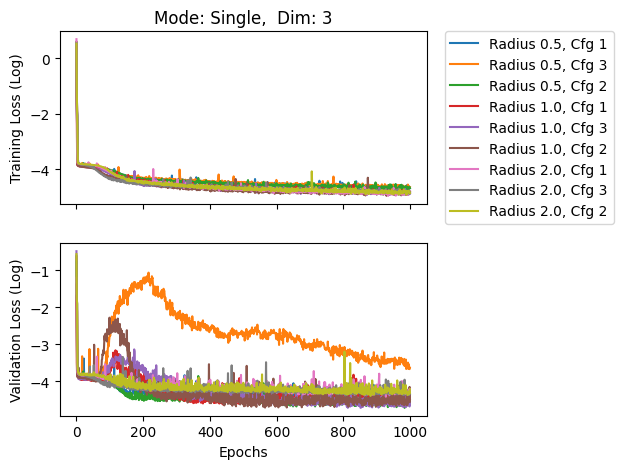

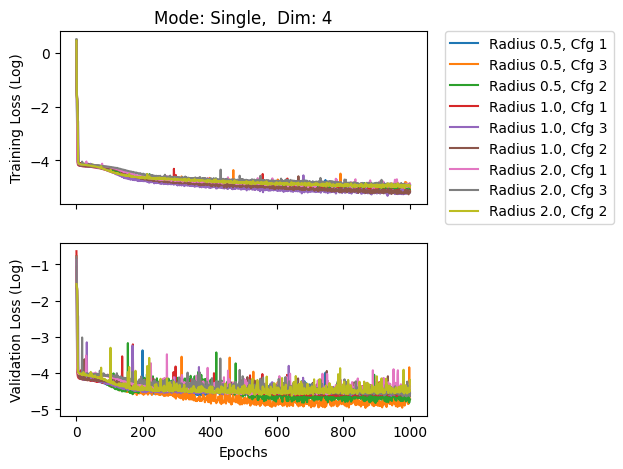

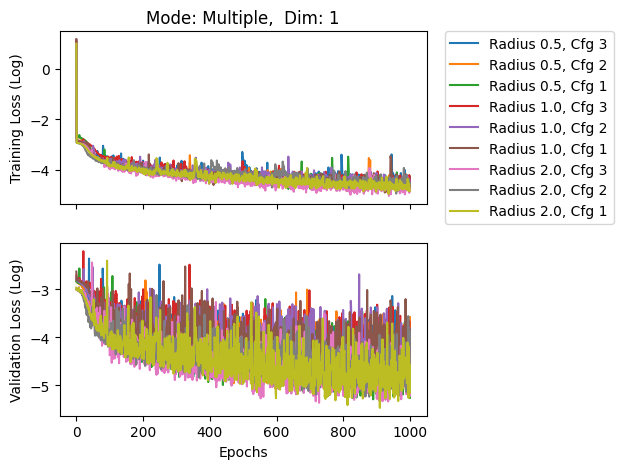

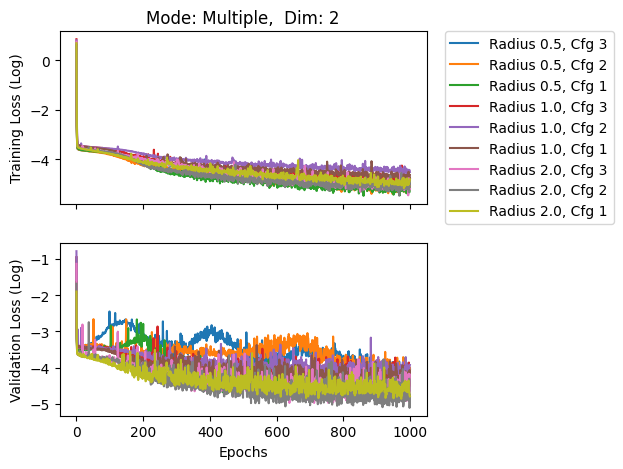

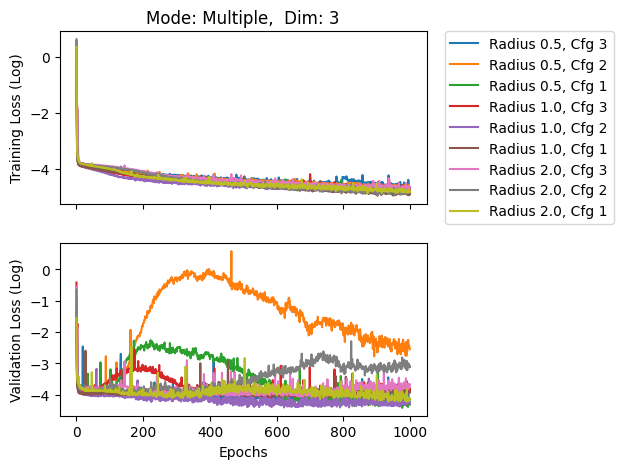

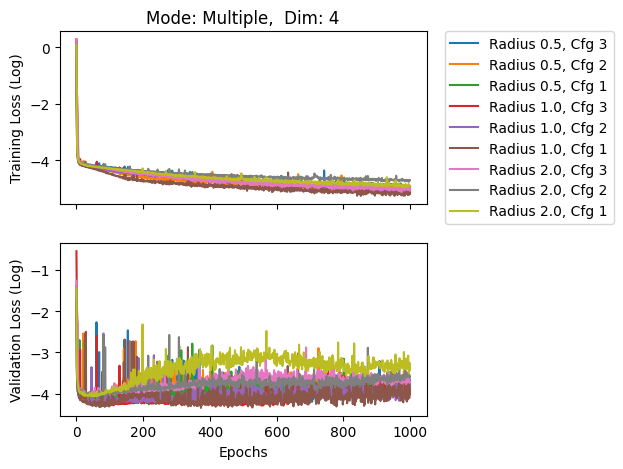

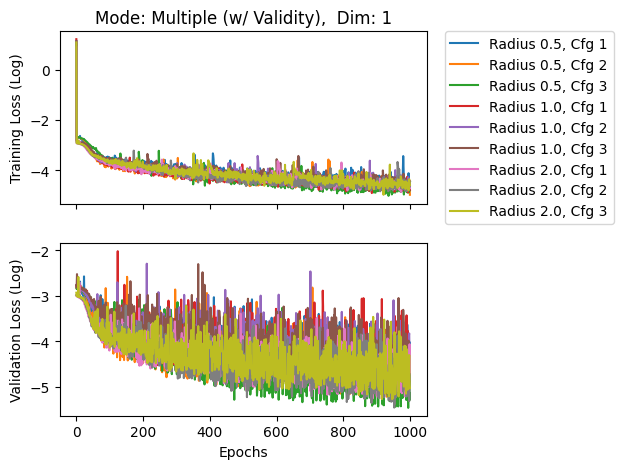

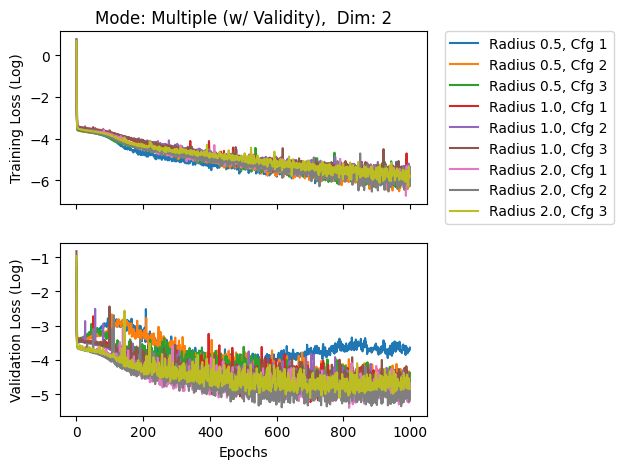

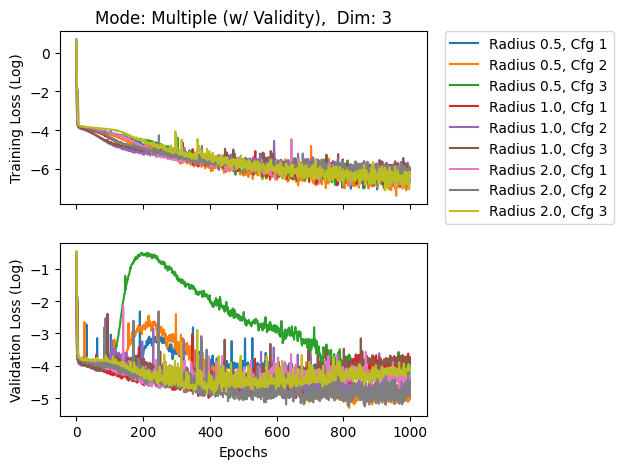

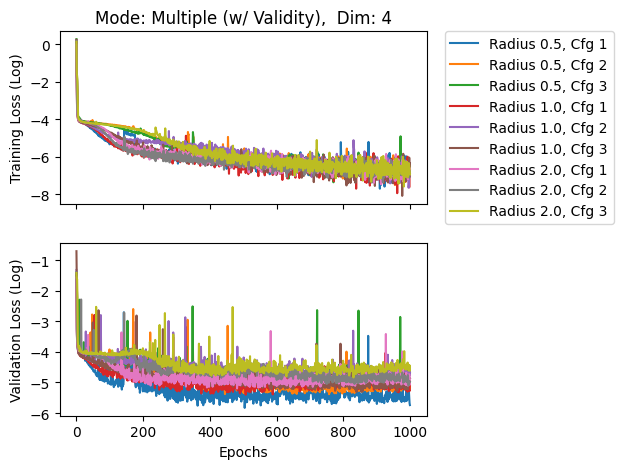

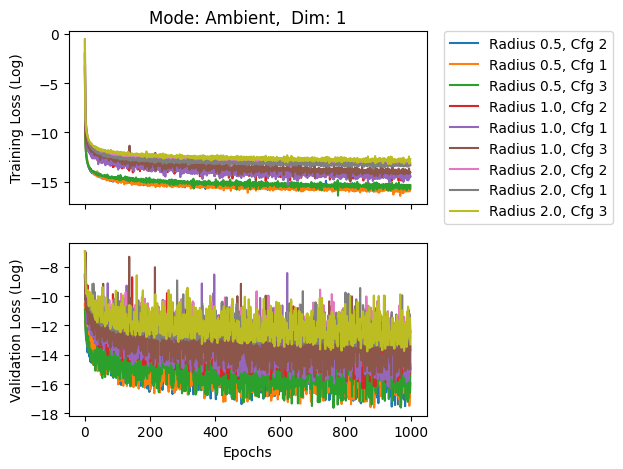

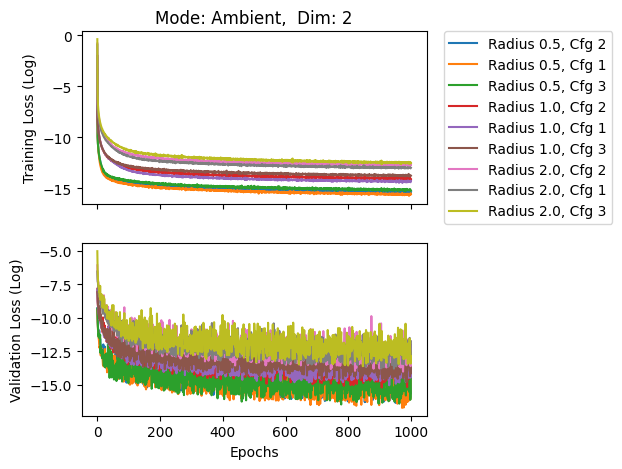

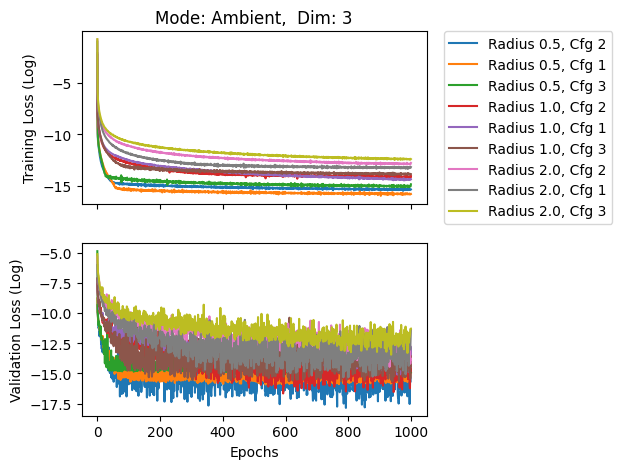

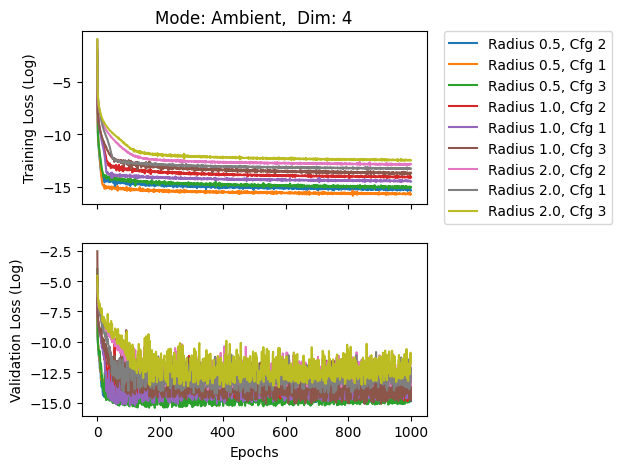

In [6]:
# plot the training/validation for each mode at each dimension
for mode, dim in itertools.product(MODES, DIMS):
    title = f"Mode: {mode},  Dim: {dim}"

    training_data_for_mode = list(
        filter(lambda data: data["mode"].value == MODES.index(mode) and data["n"] == dim, training_data))

    fig, (train_ax, valid_ax) = plt.subplots(2, 1)
    train_ax.set_title(title)
    for data in training_data_for_mode:
        label = f"Radius {data["radius"]}, {get_cfg_label(data["num_hidden_layers"], data["num_nodes_in_hidden_layer"])}"

        train_ax.plot(np.log(data["train_mean_batch_loss_hist"]), label=label)
        valid_ax.plot(np.log(data["valid_mean_batch_loss_hist"]), label=label)

    train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    # valid_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    train_ax.set_ylabel("Training Loss (Log)")
    train_ax.tick_params(labelbottom=False)
    valid_ax.set_ylabel("Validation Loss (Log)")
    valid_ax.set_xlabel("Epochs")

    plt.tight_layout()
    # valid_ax.legend(
    #     # bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    #     loc='upper center',
    #     bbox_to_anchor=(0.5, -0.20),  # move below plot
    #     ncol=4)

Mode: Single,  Dim: 1
Mode: Single,  Dim: 2
Mode: Single,  Dim: 3
Mode: Single,  Dim: 4
Mode: Multiple,  Dim: 1
Mode: Multiple,  Dim: 2
Mode: Multiple,  Dim: 3
Mode: Multiple,  Dim: 4
Mode: Multiple (w/ Validity),  Dim: 1
Mode: Multiple (w/ Validity),  Dim: 2
Mode: Multiple (w/ Validity),  Dim: 3
Mode: Multiple (w/ Validity),  Dim: 4
Mode: Ambient,  Dim: 1
Mode: Ambient,  Dim: 2
Mode: Ambient,  Dim: 3
Mode: Ambient,  Dim: 4


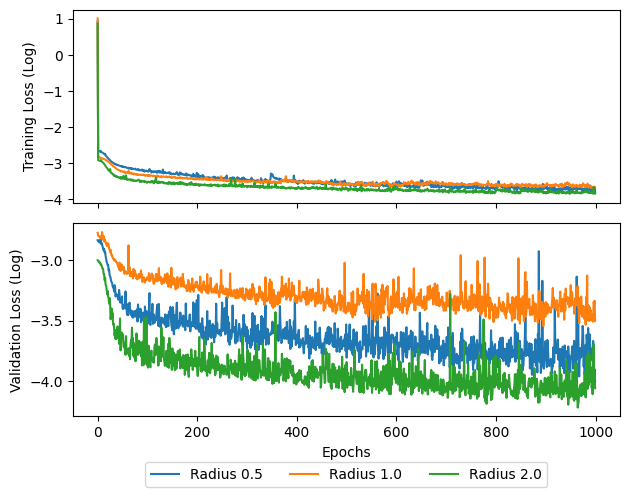

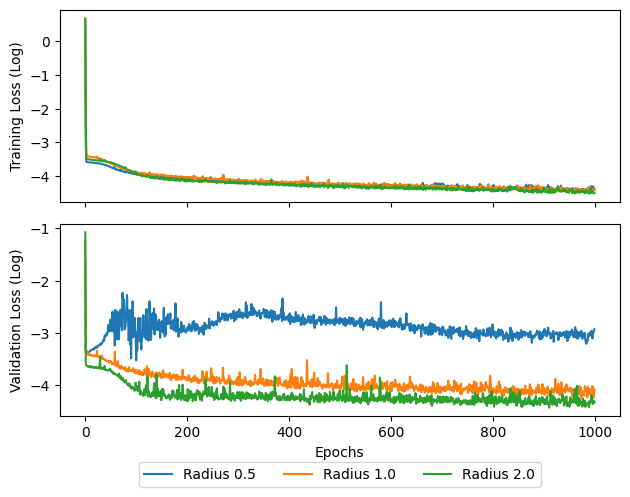

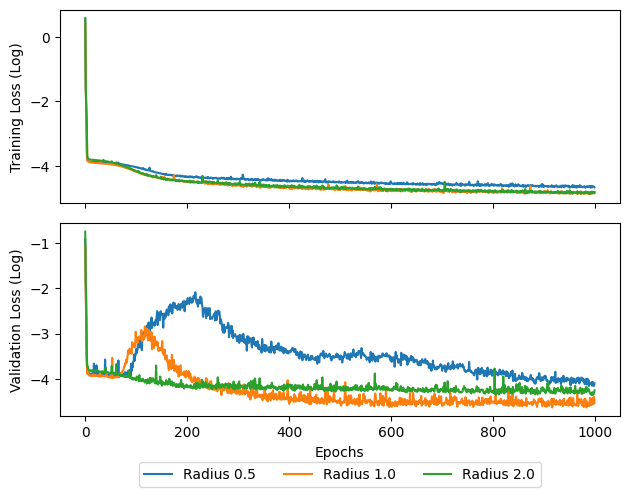

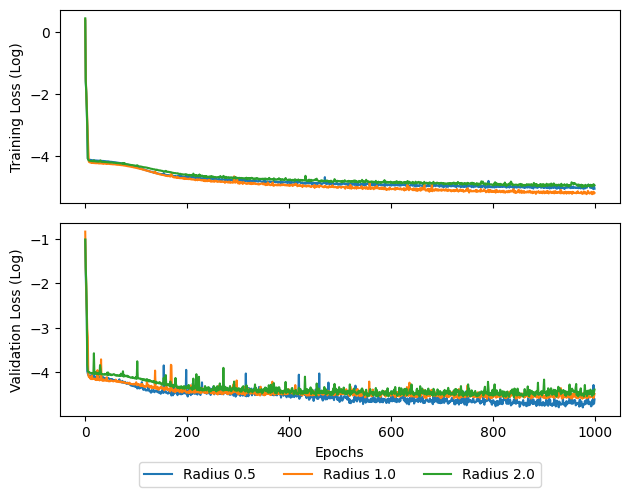

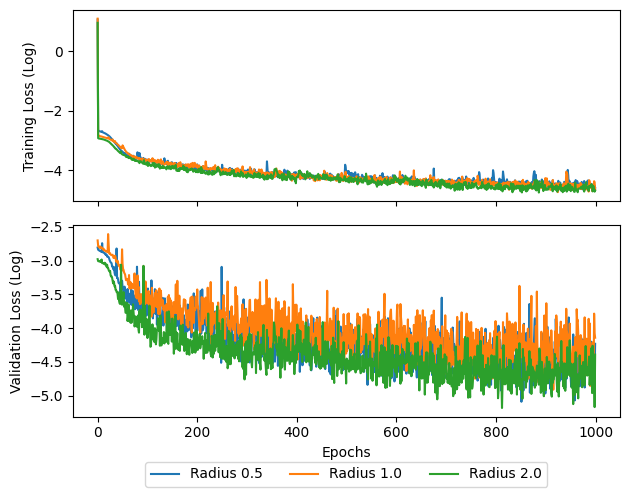

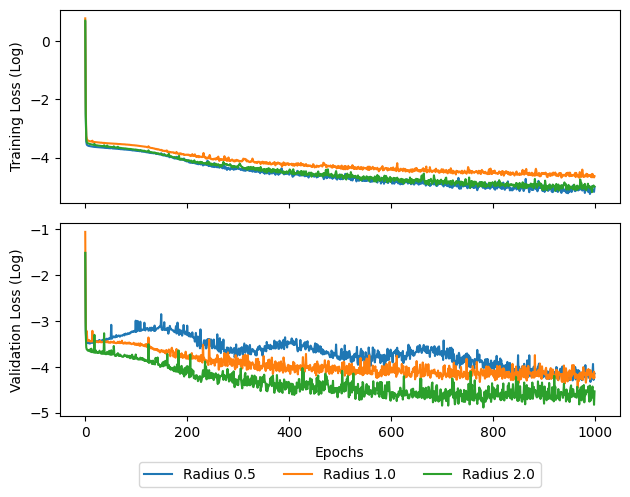

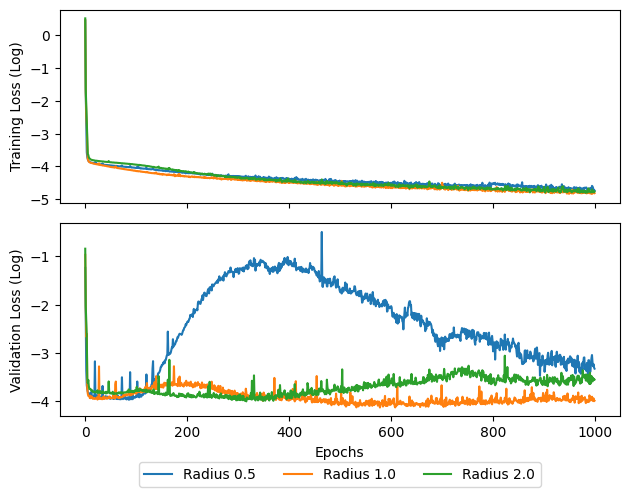

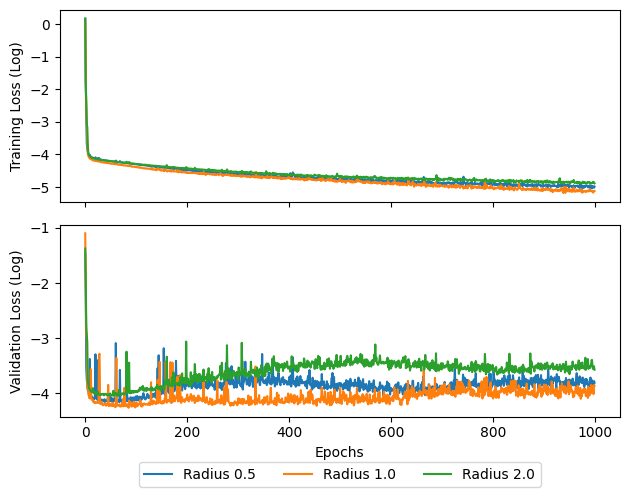

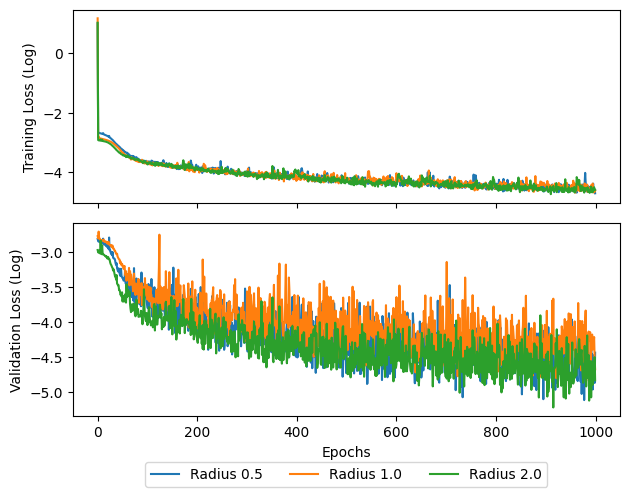

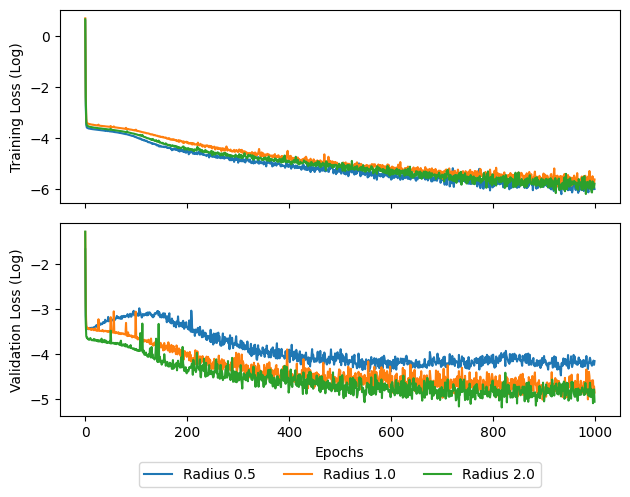

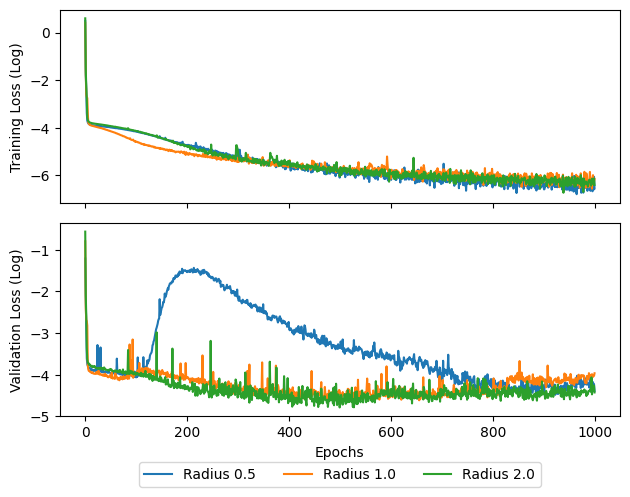

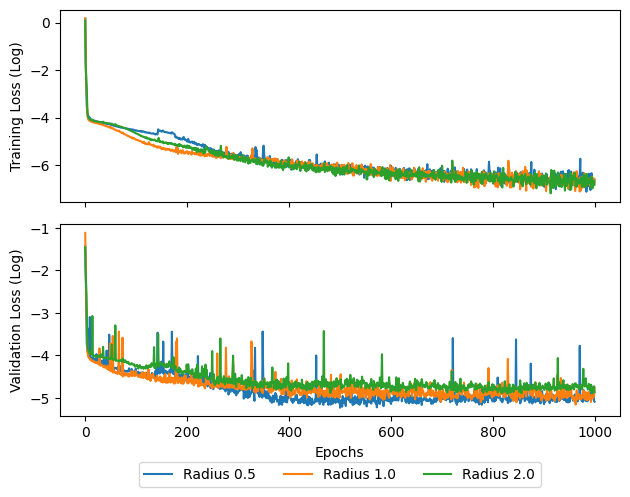

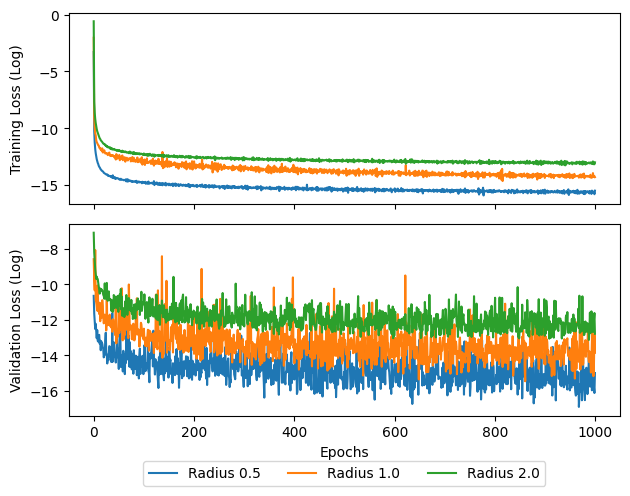

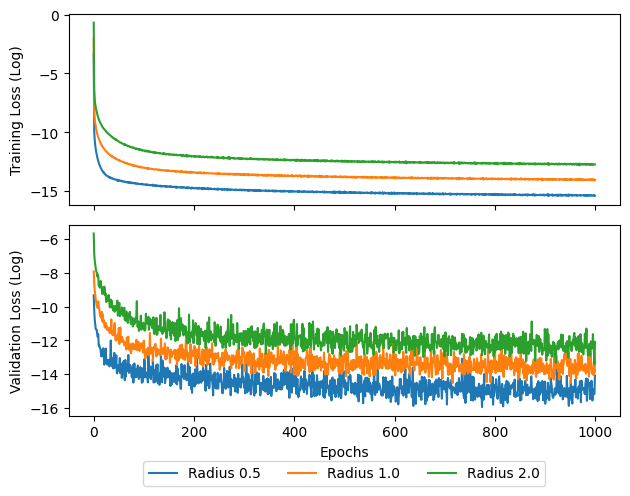

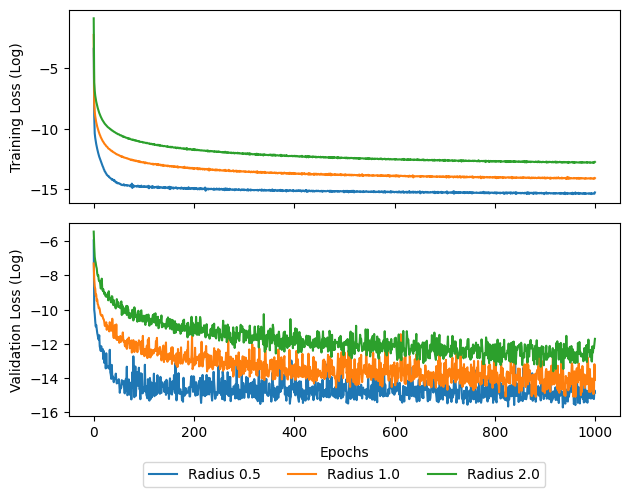

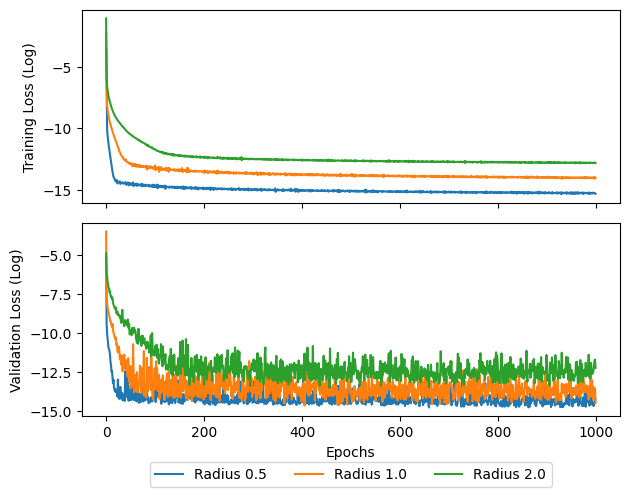

In [7]:
# present the same graphs with the values averaged across configurations
for mode, dim in itertools.product(MODES, DIMS):
    title = f"Mode: {mode},  Dim: {dim}"

    training_data_for_mode = list(
        filter(lambda data: data["mode"].value == MODES.index(mode) and data["n"] == dim, training_data))
    cfg_data_for_radius = [
        list(filter(lambda data: data["radius"] == radius, training_data_for_mode)) for radius in RADII
    ]

    fig, (train_ax, valid_ax) = plt.subplots(2, 1)
    # train_ax.set_title(title)
    print(title)
    for radius, cfg_data in zip(RADII, cfg_data_for_radius):
        label = f"Radius {radius}"

        avg_cfg_train_loss = sum(data["train_mean_batch_loss_hist"] for data in cfg_data) / len(cfg_data)
        avg_cfg_valid_loss = sum(data["valid_mean_batch_loss_hist"] for data in cfg_data) / len(cfg_data)

        train_ax.plot(np.log(avg_cfg_train_loss), label=label)
        valid_ax.plot(np.log(avg_cfg_valid_loss), label=label)

    # train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    # valid_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    train_ax.set_ylabel("Training Loss (Log)")
    train_ax.tick_params(labelbottom=False)
    valid_ax.set_ylabel("Validation Loss (Log)")
    valid_ax.set_xlabel("Epochs")

    plt.tight_layout()
    valid_ax.legend(
        # bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        loc='upper center',
        bbox_to_anchor=(0.5, -0.20),  # move below plot
        ncol=4)

Dim: 1, Radius: 0.5
Dim: 1, Radius: 1.0
Dim: 1, Radius: 2.0
Dim: 2, Radius: 0.5
Dim: 2, Radius: 1.0
Dim: 2, Radius: 2.0
Dim: 3, Radius: 0.5
Dim: 3, Radius: 1.0
Dim: 3, Radius: 2.0
Dim: 4, Radius: 0.5
Dim: 4, Radius: 1.0
Dim: 4, Radius: 2.0


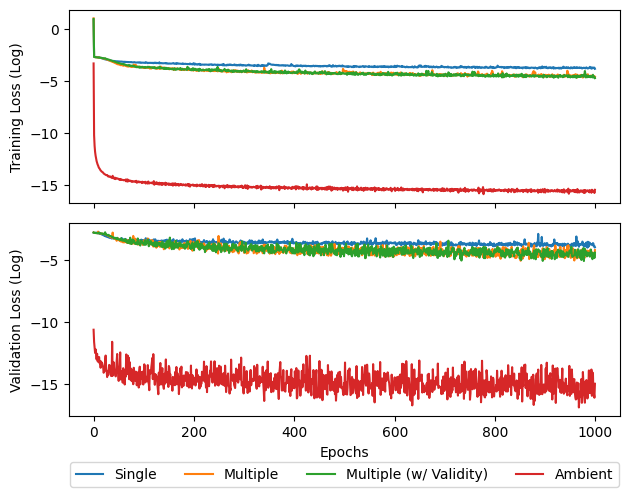

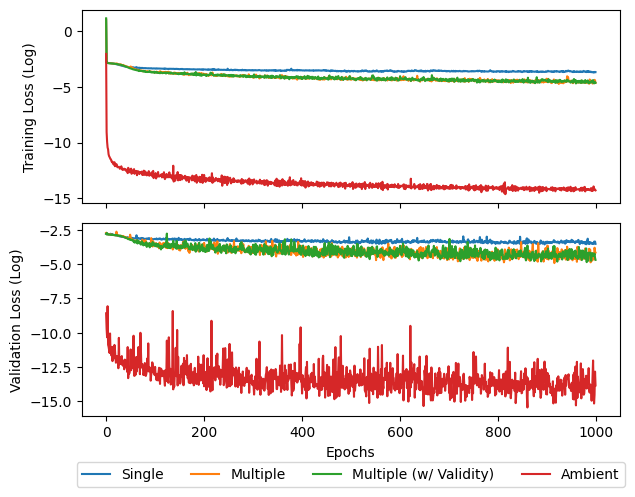

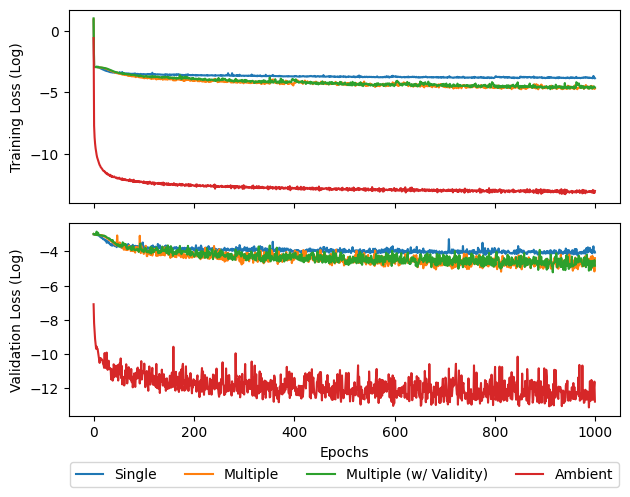

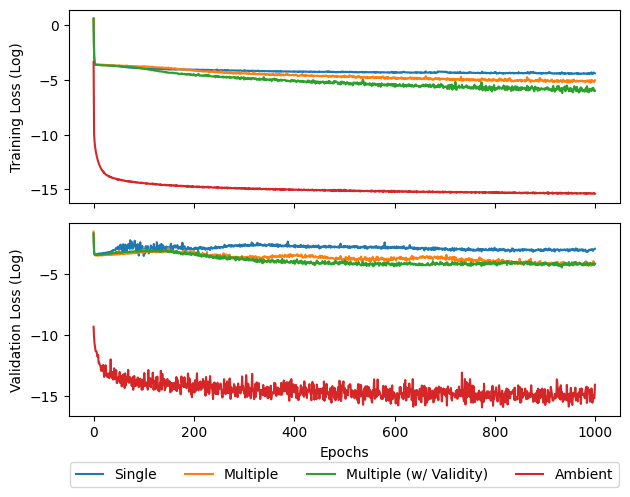

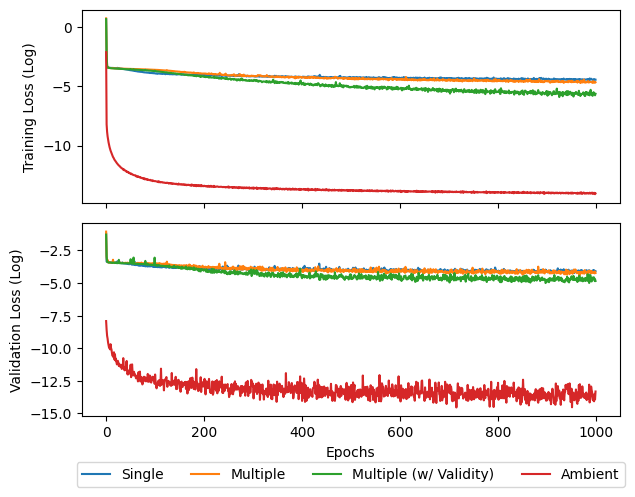

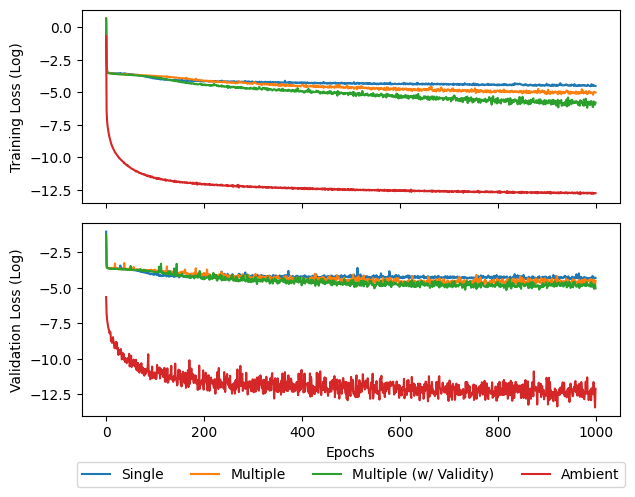

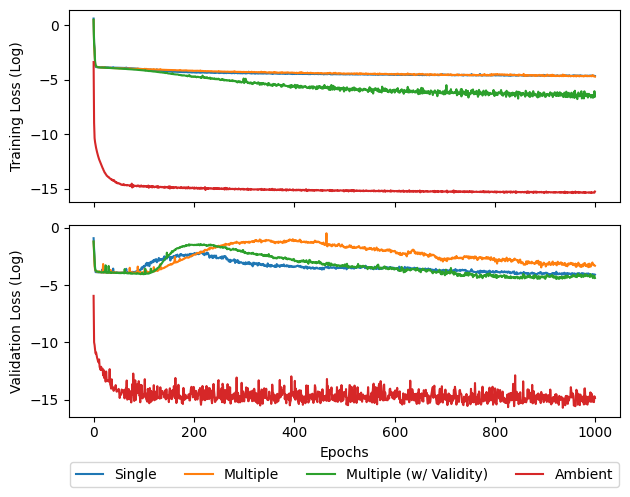

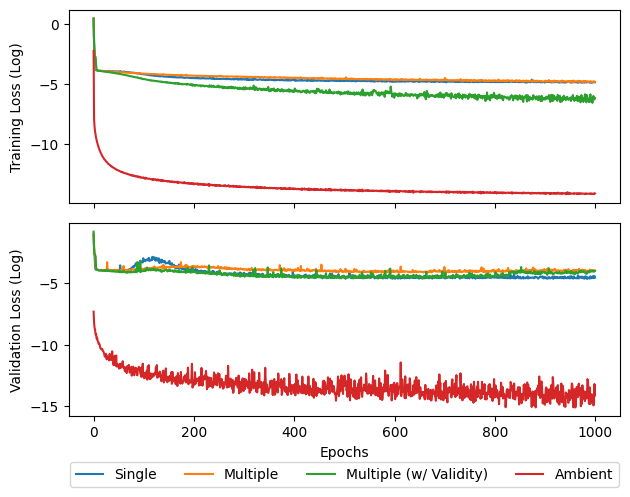

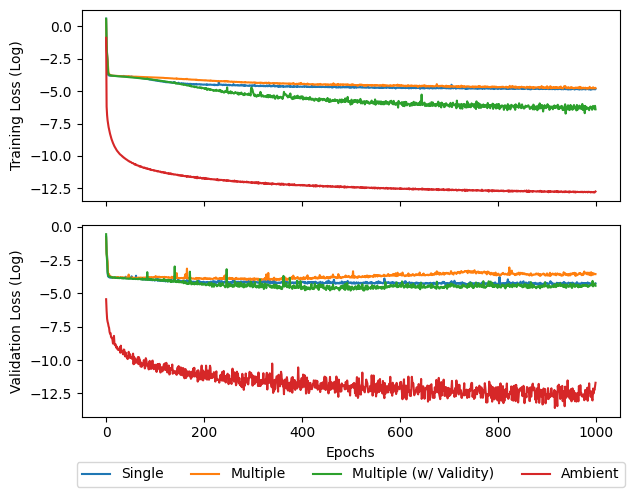

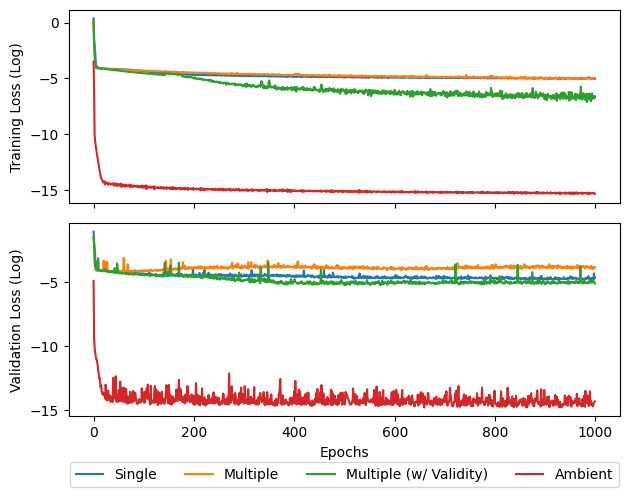

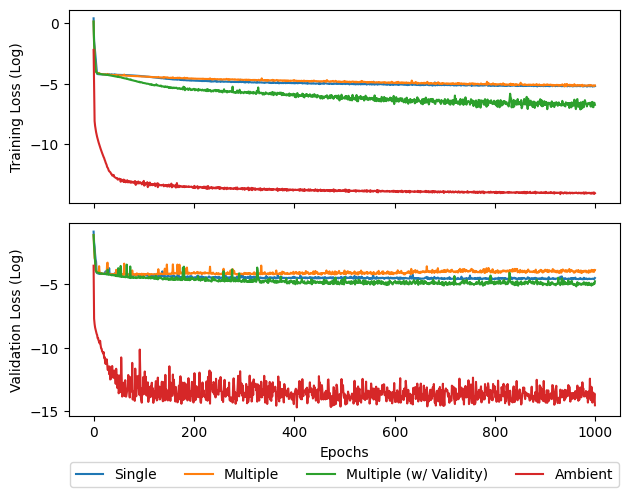

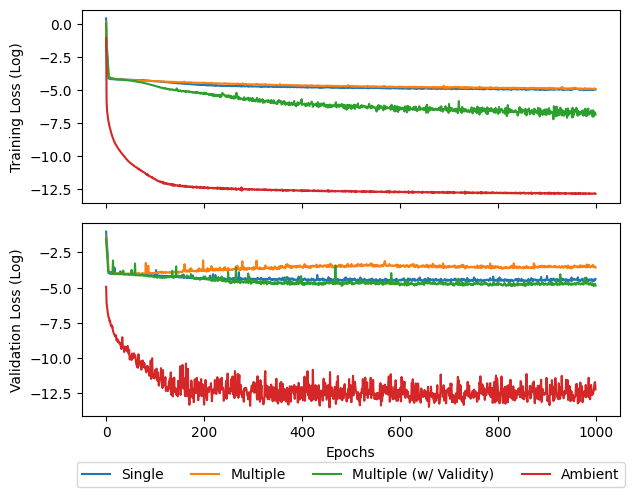

In [8]:
# compare the losses between modes at each dimension/radius so that way we can directly compare performance between each intrinsic method
for dim, radius in itertools.product(DIMS, RADII):
    title = f"Dim: {dim}, Radius: {radius}"

    training_data_for_dim_radius = list(
        filter(lambda data: data["n"] == dim and data["radius"] == radius, training_data)
    )
    cfg_data_for_mode = [
        list(filter(lambda data: data["mode"].value == mode_idx, training_data_for_dim_radius)) for mode_idx in
        range(len(MODES))
    ]

    fig, (train_ax, valid_ax) = plt.subplots(2, 1)
    # train_ax.set_title(title)
    print(title)
    for mode, cfg_data in zip(MODES, cfg_data_for_mode):
        label = mode

        avg_cfg_train_loss = sum(data["train_mean_batch_loss_hist"] for data in cfg_data) / len(cfg_data)
        avg_cfg_valid_loss = sum(data["valid_mean_batch_loss_hist"] for data in cfg_data) / len(cfg_data)

        train_ax.plot(np.log(avg_cfg_train_loss), label=label)
        valid_ax.plot(np.log(avg_cfg_valid_loss), label=label)
    train_ax.set_ylabel("Training Loss (Log)")
    train_ax.tick_params(labelbottom=False)
    valid_ax.set_ylabel("Validation Loss (Log)")
    valid_ax.set_xlabel("Epochs")


    plt.tight_layout()
    valid_ax.legend(
        # bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
        loc='upper center',
        bbox_to_anchor=(0.5, -0.20),  # move below plot
        ncol=4)

(Mean) Dim: 1
(Mean) Dim: 2
(Mean) Dim: 3
(Mean) Dim: 4


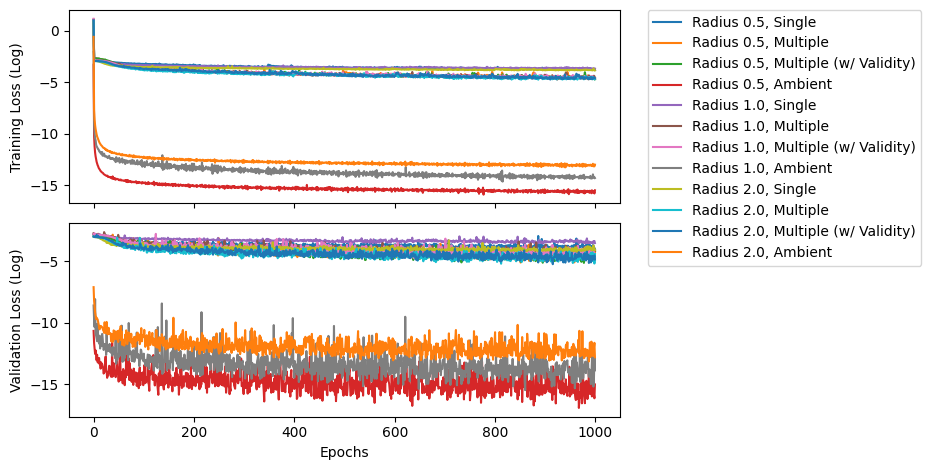

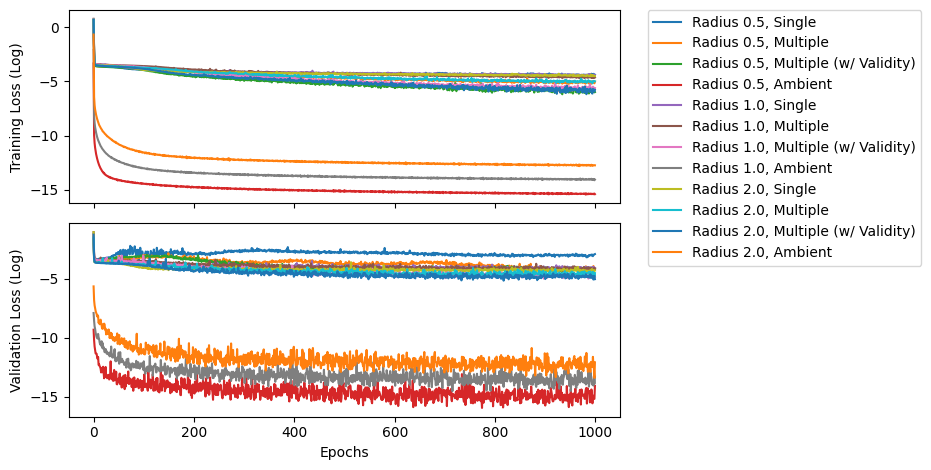

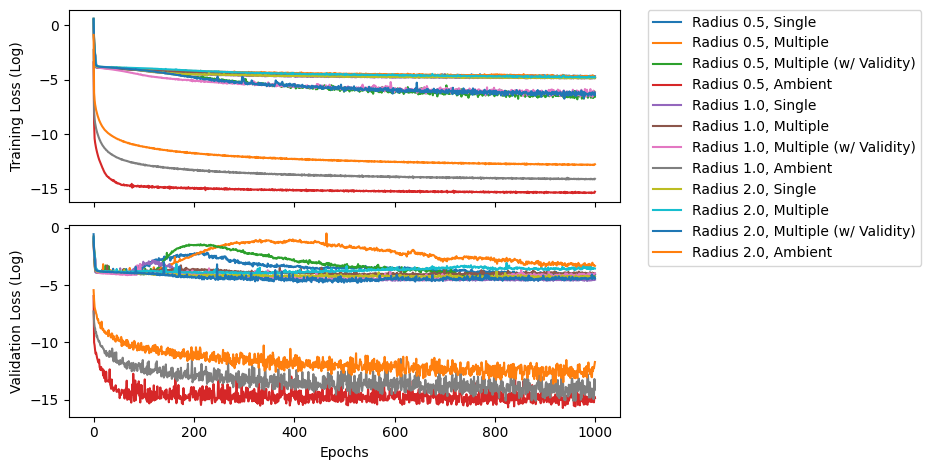

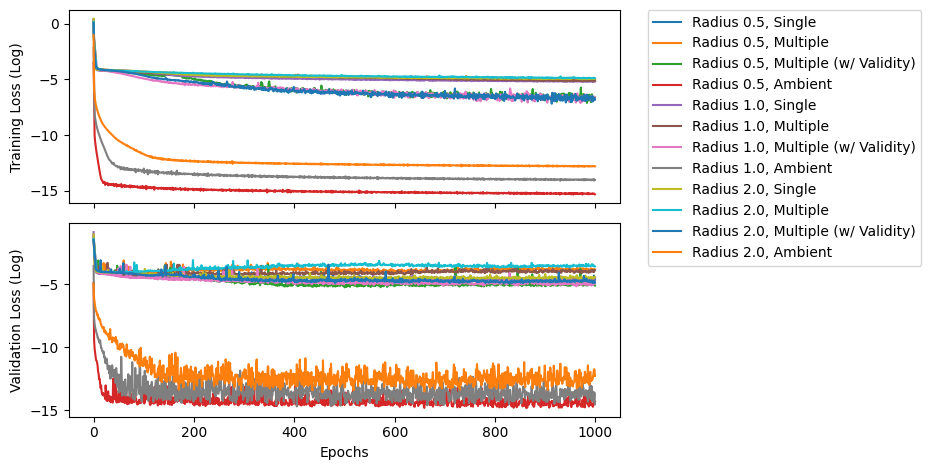

In [9]:
# for purposes of comparison then lets combine all radii results into single graphs so we can make comparisons on training performance
for dim in DIMS:
    title = f"(Mean) Dim: {dim}"

    training_data_for_dim = list(
        filter(lambda data: data["n"] == dim, training_data)
    )
    mode_radius_cfgs = list(itertools.product(range(len(MODES)), RADII))
    mode_radius_cfgs.sort(key=lambda x: x[1])
    cfg_data_for_mode_radius = [
        list(filter(lambda data: data["mode"].value == mode_idx and data["radius"] == radius,
                    training_data_for_dim)) for mode_idx, radius in mode_radius_cfgs
    ]

    fig, (train_ax, valid_ax) = plt.subplots(2, 1)
    # train_ax.set_title(title)
    print(title)
    for (mode_idx, radius), cfg_data in zip(mode_radius_cfgs, cfg_data_for_mode_radius):
        label = f"Radius {radius}, {MODES[mode_idx]}"

        avg_cfg_train_loss = sum(data["train_mean_batch_loss_hist"] for data in cfg_data) / len(cfg_data)
        avg_cfg_valid_loss = sum(data["valid_mean_batch_loss_hist"] for data in cfg_data) / len(cfg_data)

        train_ax.plot(np.log(avg_cfg_train_loss), label=label)
        valid_ax.plot(np.log(avg_cfg_valid_loss), label=label)

    train_ax.set_ylabel("Training Loss (Log)")
    train_ax.tick_params(labelbottom=False)
    valid_ax.set_ylabel("Validation Loss (Log)")
    valid_ax.set_xlabel("Epochs")

    plt.tight_layout()
    train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    # valid_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


(Max) Dim: 1
(Max) Dim: 2
(Max) Dim: 3
(Max) Dim: 4


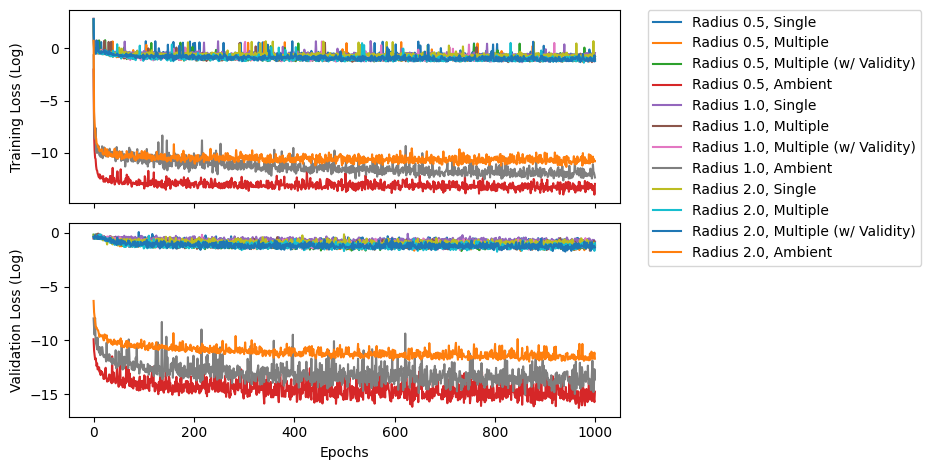

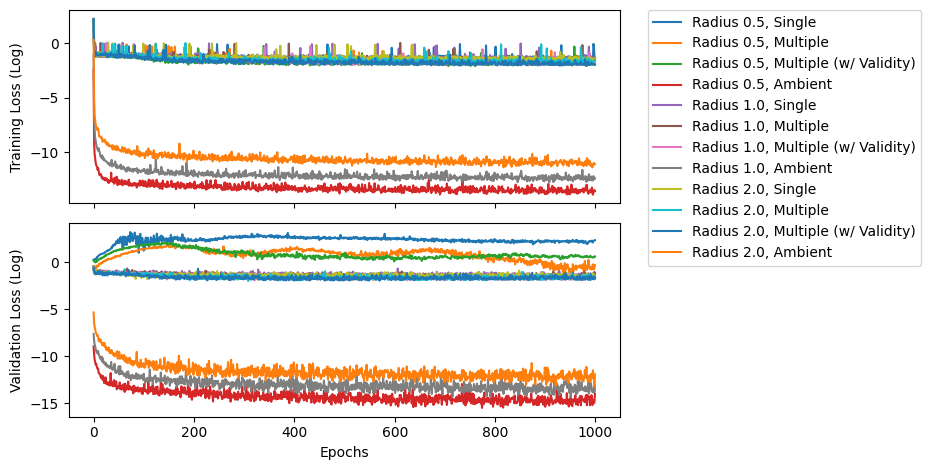

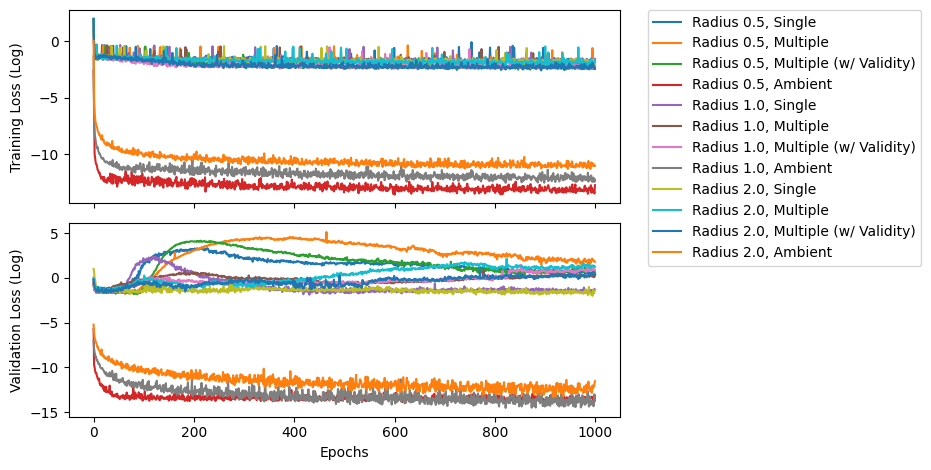

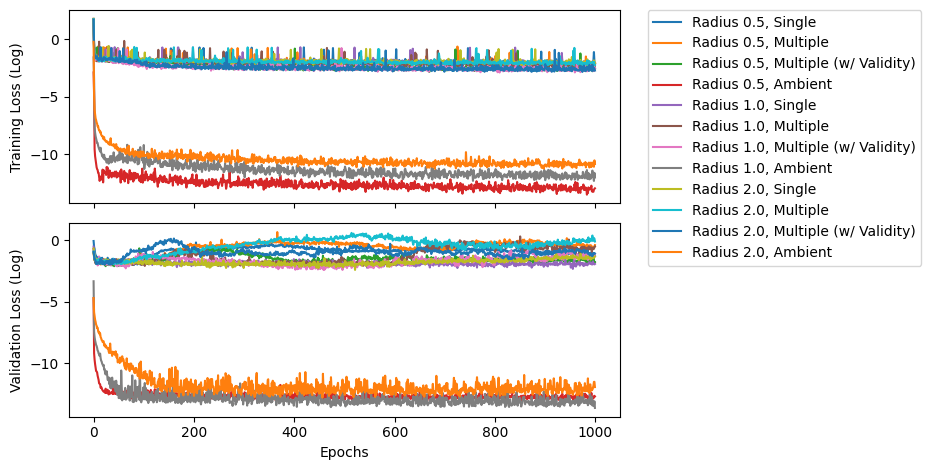

In [10]:
# complete the previous assessment with the worst case batch loss
for dim in DIMS:
    title = f"(Max) Dim: {dim}"

    training_data_for_dim = list(
        filter(lambda data: data["n"] == dim, training_data)
    )
    mode_radius_cfgs = list(itertools.product(range(len(MODES)), RADII))
    mode_radius_cfgs.sort(key=lambda x: x[1])
    cfg_data_for_mode_radius = [
        list(filter(lambda data: data["mode"].value == mode_idx and data["radius"] == radius,
                    training_data_for_dim)) for mode_idx, radius in mode_radius_cfgs
    ]

    fig, (train_ax, valid_ax) = plt.subplots(2, 1, sharex="row")
    print(title)
    # train_ax.set_title(title)
    for (mode_idx, radius), cfg_data in zip(mode_radius_cfgs, cfg_data_for_mode_radius):
        label = f"Radius {radius}, {MODES[mode_idx]}"

        avg_cfg_train_loss = sum(data["train_max_batch_loss_hist"] for data in cfg_data) / len(cfg_data)
        avg_cfg_valid_loss = sum(data["valid_max_batch_loss_hist"] for data in cfg_data) / len(cfg_data)

        train_ax.plot(np.log(avg_cfg_train_loss), label=label)
        valid_ax.plot(np.log(avg_cfg_valid_loss), label=label)

    train_ax.set_ylabel("Training Loss (Log)")
    train_ax.tick_params(labelbottom=False)
    valid_ax.set_ylabel("Validation Loss (Log)")
    valid_ax.set_xlabel("Epochs")

    plt.tight_layout()
    train_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    # valid_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


In [11]:
# compute statistics for the final iterations (once fully trained)
avg_final_mean_train_losses = np.zeros((len(RADII), len(MODES), len(DIMS)))
std_final_mean_train_losses = np.zeros((len(RADII), len(MODES), len(DIMS)))
avg_final_mean_valid_losses = np.zeros((len(RADII), len(MODES), len(DIMS)))
std_final_mean_valid_losses = np.zeros((len(RADII), len(MODES), len(DIMS)))

avg_final_max_train_losses = np.zeros((len(RADII), len(MODES), len(DIMS)))
std_final_max_train_losses = np.zeros((len(RADII), len(MODES), len(DIMS)))
avg_final_max_valid_losses = np.zeros((len(RADII), len(MODES), len(DIMS)))
std_final_max_valid_losses = np.zeros((len(RADII), len(MODES), len(DIMS)))

EPOCHS_TO_AVG = 100

for data in training_data:
    radius_idx = RADII.index(data["radius"])
    mode_idx = data["mode"].value
    dim_idx = DIMS.index(data["n"])

    mean_final_train_rel_losses = data["train_mean_batch_loss_hist"][-EPOCHS_TO_AVG:]
    mean_final_valid_rel_losses = data["valid_mean_batch_loss_hist"][-EPOCHS_TO_AVG:]

    max_final_train_rel_losses = data["train_max_batch_loss_hist"][-EPOCHS_TO_AVG:]
    max_final_valid_rel_losses = data["valid_max_batch_loss_hist"][-EPOCHS_TO_AVG:]

    # takes average
    avg_final_mean_train_losses[radius_idx, mode_idx, dim_idx] = np.mean(mean_final_train_rel_losses)
    std_final_mean_train_losses[radius_idx, mode_idx, dim_idx] = np.std(mean_final_train_rel_losses)

    avg_final_mean_valid_losses[radius_idx, mode_idx, dim_idx] = np.mean(mean_final_valid_rel_losses)
    std_final_mean_valid_losses[radius_idx, mode_idx, dim_idx] = np.std(mean_final_valid_rel_losses)

    avg_final_max_train_losses[radius_idx, mode_idx, dim_idx] = np.mean(max_final_train_rel_losses)
    std_final_max_train_losses[radius_idx, mode_idx, dim_idx] = np.std(max_final_train_rel_losses)

    avg_final_max_valid_losses[radius_idx, mode_idx, dim_idx] = np.mean(max_final_valid_rel_losses)
    std_final_max_valid_losses[radius_idx, mode_idx, dim_idx] = np.std(max_final_valid_rel_losses)

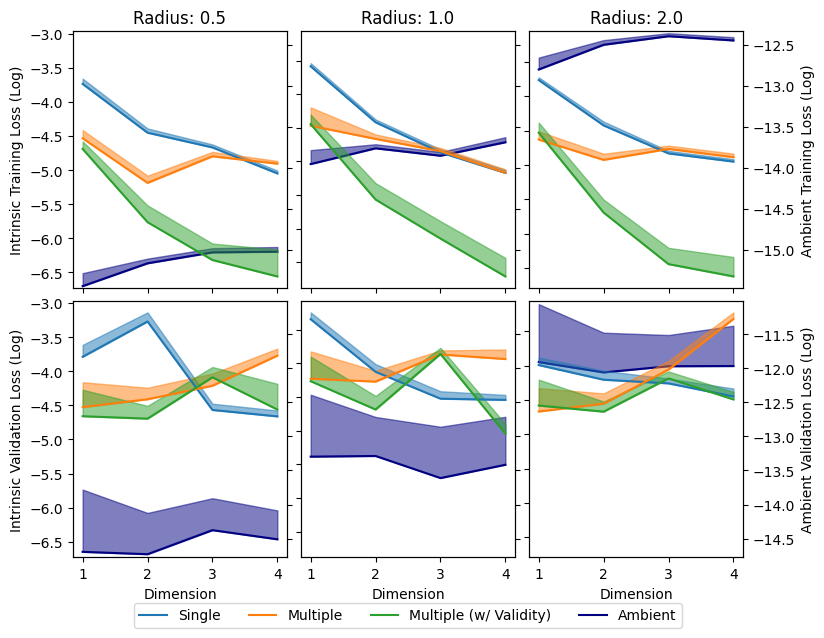

In [12]:
# computes the average steady-state train/valid loss vs dimension
fig, axes = plt.subplots(2, 3, constrained_layout=False, figsize=(8, 6), sharex='row', sharey='col')
twins = [[ax.twinx() for ax in row] for row in axes]

for radius_idx in range(len(RADII)):
    train_ax, valid_ax = axes[0, radius_idx], axes[1, radius_idx]
    train_ax_twin, valid_ax_twin = twins[0][radius_idx], twins[1][radius_idx]

    # renders so we place the secondary axis (with extrinsic data) below the intrinsic data
    train_ax.patch.set_visible(False)
    train_ax_twin.set_zorder(train_ax.get_zorder() - 1)
    valid_ax.patch.set_visible(False)
    valid_ax_twin.set_zorder(valid_ax.get_zorder() - 1)

    title = f"Radius: {RADII[radius_idx]}"
    train_ax.set_title(title)
    for mode_idx in range(len(MODES)):
        label = MODES[mode_idx]

        # gets the training/validation data for the current radius and mode
        mode_mean_train_data = avg_final_mean_train_losses[radius_idx, mode_idx, :]
        mode_mean_std_train_data = std_final_mean_train_losses[radius_idx, mode_idx, :]
        mode_max_train_data = avg_final_max_train_losses[radius_idx, mode_idx, :]
        mode_max_std_train_data = std_final_max_train_losses[radius_idx, mode_idx, :]

        mode_mean_valid_data = avg_final_mean_valid_losses[radius_idx, mode_idx, :]
        mode_mean_std_valid_data = std_final_mean_valid_losses[radius_idx, mode_idx, :]
        mode_max_valid_data = avg_final_max_valid_losses[radius_idx, mode_idx, :]
        mode_max_std_valid_data = std_final_max_valid_losses[radius_idx, mode_idx, :]

        # performs a check to see if this is the ambient mode so we can color the line red
        is_ambient = mode_idx == 3
        if is_ambient:
            sel_train_ax, sel_valid_ax = train_ax_twin, valid_ax_twin
        else:
            sel_train_ax, sel_valid_ax = train_ax, valid_ax
        color = "navy" if is_ambient else None

        train_line, = sel_train_ax.plot(DIMS, np.log(mode_mean_train_data), label=label, color=color)
        sel_train_ax.fill_between(DIMS,
                                  np.log(mode_mean_train_data),
                                  np.log(mode_mean_train_data + mode_mean_std_train_data),
                                  # np.log(mode_max_train_data),
                                  alpha=0.5, color=train_line.get_color())

        valid_line, = sel_valid_ax.plot(DIMS, np.log(mode_mean_valid_data), label=label, color=color)
        sel_valid_ax.fill_between(DIMS,
                                  np.log(mode_mean_valid_data),
                                  np.log(mode_mean_valid_data + mode_mean_std_valid_data),
                                  # np.log(mode_max_valid_data),
                                  alpha=0.5, color=valid_line.get_color())

    train_ax.set_xticks(DIMS, DIMS)
    valid_ax.set_xticks(DIMS, DIMS)

for ax in axes[:, 1:].flatten():
    ax.tick_params(labelleft=False)
for ax in axes[0, :].flatten():
    ax.tick_params(labelbottom=False)

for row in twins:
    min_twin_ylim = min(ax.get_ylim()[0] for ax in row)
    max_twin_ylim = max(ax.get_ylim()[1] for ax in row)

    num_in_row = len(row)
    for i, ax in enumerate(row):
        ax.set_ylim((min_twin_ylim, max_twin_ylim))
        if i != num_in_row - 1:
            ax.tick_params(labelright=False)

axes[0, 0].set_ylabel("Intrinsic Training Loss (Log)")
axes[1, 0].set_ylabel("Intrinsic Validation Loss (Log)")

twins[0][2].set_ylabel("Ambient Training Loss (Log)")
twins[1][2].set_ylabel("Ambient Validation Loss (Log)")

axes[1, 0].set_xlabel("Dimension")
axes[1, 1].set_xlabel("Dimension")
axes[1, 2].set_xlabel("Dimension")

plt.tight_layout(pad=0.3)

train_leg_lines, train_leg_labels = axes[0, 0].get_legend_handles_labels()
twin_train_leg_lines, twin_train_leg_labels = twins[0][0].get_legend_handles_labels()

axes[1, 1].legend(train_leg_lines + twin_train_leg_lines,
                  train_leg_labels + twin_train_leg_labels,
                  # bbox_to_anchor=(1.15, 1), loc='upper left', borderaxespad=0.)
                  loc='upper center',
                  bbox_to_anchor=(0.5, -0.15),  # move below plot
                  ncol=4)

plt.show()

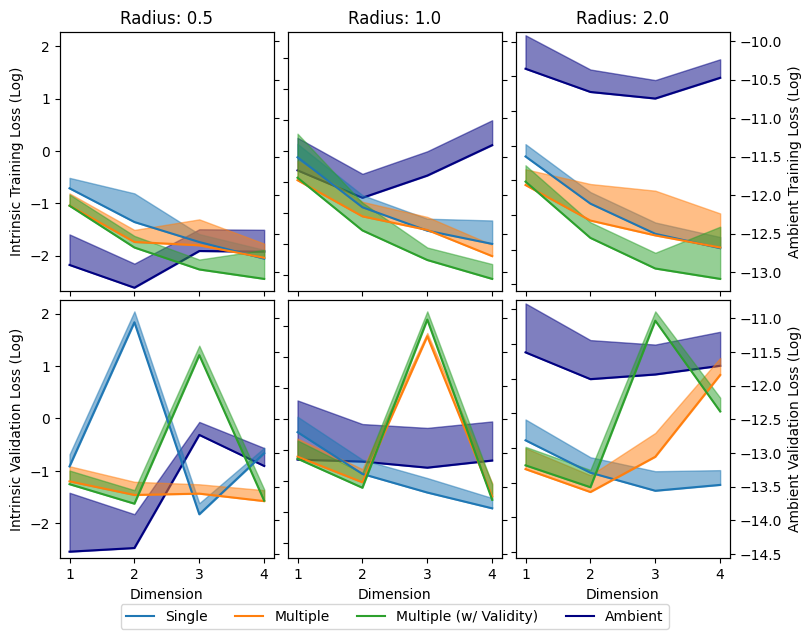

In [13]:
# computes the maximum steady-state train/valid loss vs dimension
fig, axes = plt.subplots(2, 3, constrained_layout=False, figsize=(8, 6), sharex='row', sharey='col')
twins = [[ax.twinx() for ax in row] for row in axes]

for radius_idx in range(len(RADII)):
    train_ax, valid_ax = axes[0, radius_idx], axes[1, radius_idx]
    train_ax_twin, valid_ax_twin = twins[0][radius_idx], twins[1][radius_idx]

    # renders so we place the secondary axis (with validation data) below the training data
    train_ax.patch.set_visible(False)
    train_ax_twin.set_zorder(train_ax.get_zorder() - 1)
    valid_ax.patch.set_visible(False)
    valid_ax_twin.set_zorder(valid_ax.get_zorder() - 1)

    title = f"Radius: {RADII[radius_idx]}"
    train_ax.set_title(title)
    for mode_idx in range(len(MODES)):
        label = MODES[mode_idx]

        # gets the training/validation data for the current radius and mode
        mode_max_train_data = avg_final_max_train_losses[radius_idx, mode_idx, :]
        mode_max_std_train_data = std_final_max_train_losses[radius_idx, mode_idx, :]
        mode_max_valid_data = avg_final_max_valid_losses[radius_idx, mode_idx, :]
        mode_max_std_valid_data = std_final_max_valid_losses[radius_idx, mode_idx, :]

        # performs a check to see if this is the ambient mode so we can color the line red
        is_ambient = mode_idx == 3
        if is_ambient:
            sel_train_ax, sel_valid_ax = train_ax_twin, valid_ax_twin
        else:
            sel_train_ax, sel_valid_ax = train_ax, valid_ax
        color = "navy" if is_ambient else None

        train_line, = sel_train_ax.plot(DIMS, np.log(mode_max_train_data), label=label, color=color)
        sel_train_ax.fill_between(DIMS,
                                  np.log(mode_max_train_data),
                                  np.log(mode_max_train_data + mode_max_std_train_data),
                                  # np.log(mode_max_train_data),
                                  alpha=0.5, color=train_line.get_color())

        valid_line, = sel_valid_ax.plot(DIMS, np.log(mode_max_valid_data), label=label, color=color)
        sel_valid_ax.fill_between(DIMS,
                                  np.log(mode_max_valid_data),
                                  np.log(mode_max_valid_data + mode_max_std_valid_data),
                                  # np.log(mode_max_valid_data),
                                  alpha=0.5, color=valid_line.get_color())

    train_ax.set_xticks(DIMS, DIMS)
    valid_ax.set_xticks(DIMS, DIMS)

for ax in axes[:, 1:].flatten():
    ax.tick_params(labelleft=False)
for ax in axes[0, :].flatten():
    ax.tick_params(labelbottom=False)

for row in twins:
    min_twin_ylim = min(ax.get_ylim()[0] for ax in row)
    max_twin_ylim = max(ax.get_ylim()[1] for ax in row)

    num_in_row = len(row)
    for i, ax in enumerate(row):
        ax.set_ylim((min_twin_ylim, max_twin_ylim))
        if i != num_in_row - 1:
            ax.tick_params(labelright=False)

axes[0, 0].set_ylabel("Intrinsic Training Loss (Log)")
axes[1, 0].set_ylabel("Intrinsic Validation Loss (Log)")

twins[0][2].set_ylabel("Ambient Training Loss (Log)")
twins[1][2].set_ylabel("Ambient Validation Loss (Log)")

axes[1, 0].set_xlabel("Dimension")
axes[1, 1].set_xlabel("Dimension")
axes[1, 2].set_xlabel("Dimension")

plt.tight_layout(pad=0.3)

train_leg_lines, train_leg_labels = axes[0, 0].get_legend_handles_labels()
twin_train_leg_lines, twin_train_leg_labels = twins[0][0].get_legend_handles_labels()

axes[1, 1].legend(train_leg_lines + twin_train_leg_lines,
                  train_leg_labels + twin_train_leg_labels,
                  # bbox_to_anchor=(1.15, 1), loc='upper left', borderaxespad=0.)
                  loc='upper center',
                  bbox_to_anchor=(0.5, -0.15),  # move below plot
                  ncol=4)

plt.show()